# <center> Сегментация клиентов онлайн магазина подарков

## Постановка задачи


<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

> Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. Однако [The UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/index.php)  создал набор данных, содержащий фактические транзакции за 2010 и 2011 годы. С ним нам как раз и предлагается поработать в этом кейсе. 

> В нашем распоряжении будет набор данных, который содержит все транзакции, произошедшие в период с 01/12/2010 по 09/12/2011 для базирующейся в Великобритании компании, занимающейся онлайн-розничной торговлей. Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовиками.


**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

## Данные и их описание

Данные представляют собой таблицу в формате CSV, в каждой строке которой содержится информация об уникальной транзакции.

Признаки, описывающие каждую транзакцию:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* StockCode — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию;
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.



Импорт базовых библиотек:

In [1]:
# подгружаем библиотеки 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

import warnings 

from IPython.display import display, HTML

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

## 🌐 Интерактивные визуализации

Все 3D-графики и интерактивные диаграммы доступны по ссылкам ниже  
(открываются в новой вкладке, можно вращать, приближать и наводить мышку):

| График | Ссылка |
|--------|--------|
| 🔍 **3D Scatter Plot** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/scatter.html) |
| 📈 **Polar Chart** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/polar_chart.html) |
| 📊 **Bar Chart - Head** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/bar_head.html) |
| 📉 **Bar Chart - Low** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/bar_low.html) |
| 📦 **Box Plots** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/boxes.html) |
| 🥧 **Pie Chart** | [Открыть](https://sibainu2010.github.io/skillfactory_ds/pie.html) |

## 1. Знакомство со структурой данных

Первым делом необходимо понять, с какими данными предстоит работать, и произвести базовую предобработку данных — перевести признаки в необходимые для дальнейшей работы форматы.


In [2]:
# загружаем данные 
data = pd.read_csv(
    r"C:\Users\79654\Downloads\pj6_data\data.csv", 
    encoding="ISO-8859-1", 
    dtype={"CustomerID": str,"InvoiceID": str}
)
print("Data shape: {}".format(data.shape))
data.head(5)

Data shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  str    
 7   Country      541909 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 33.1 MB


In [4]:
# преобразовываем наши даты транзакций во временной формат
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
print("Date interval {} to {}".format(data["InvoiceDate"].dt.date.min(), data["InvoiceDate"].dt.date.max()))

Date interval 2010-12-01 to 2011-12-09


## 2. Преобразование, очистка и анализ данных

### 2.1. Преобразование и очистка данных о транзакциях

#### 2.1.1 Пропуски


In [5]:
# смотрим кол. пропусков в данных
missing = data.isnull().sum()
missing_prc = (missing / len(data)) * 100

missing_df = pd.DataFrame({"Пропуски": missing,
                           "Пропуски в процентах": missing_prc.round(2)})

display(missing_df)
print(f"\nОбщее число пропусков в данных: {data.isnull().sum().sum()}")

,Пропуски,Пропуски в процентах
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00



Общее число пропусков в данных: 136534


In [6]:
# удаляем пропускки из данных
data = data.dropna()

print(f"\nОбщее число пропусков в данных: {data.isnull().sum().sum()}")


Общее число пропусков в данных: 0


#### 2.1.2. Дубликаты

In [7]:
# ишем дубликаты
print(f"Количество дубликатов в данных: {data.duplicated().sum()}")

Количество дубликатов в данных: 5225


In [8]:
# удаляем дубликаты 
data = data.drop_duplicates()
print(f"Количество дубликатов в данных: {data.duplicated().sum()}")

Количество дубликатов в данных: 0


#### 2.1.3. Транзакции с отрицательным количеством товара

Из приведённых выше инсайтов о данных мы узнали все особенности отмены заказов. Когда мы будем сегментировать клиентов, мы будем определять их покупательскую способность. При расчёте покупательской способности нам будет очень важно учесть возвраты этого клиента.

Чтобы подсчитать количество возвратов, для начала нам надо определить, сколько уникальных товаров указано в транзакции (корзине) для каждой уникальной пары «клиент — заказ»:


In [9]:
# количество уникальных товаров в чеке (без дубликатов)
data["CountPkg"] = data.groupby("InvoiceNo")["StockCode"].transform("nunique")
# является ли транзакция возвратом
data["IsReturn"] = data["InvoiceNo"].astype(str).str.startswith("C")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CountPkg,IsReturn
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,7,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,7,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False


In [10]:
# создаем признак возврата товара
def get_quantity_canceled(data):
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data["Quantity"] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        df_test = data[(data["CustomerID"] == col["CustomerID"]) &
                       (data["StockCode"]  == col["StockCode"]) & 
                       (data["InvoiceDate"] < col["InvoiceDate"]) & 
                       (data["Quantity"] > 0)].copy()
        if (df_test.shape[0] == 0): 
            quantity_canceled.loc[index] = np.nan
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col["Quantity"]       
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0 ,ascending=False, inplace = True)        
            for ind, val in df_test.iterrows():
                if val["Quantity"] < -col["Quantity"]: 
                    continue
                quantity_canceled.loc[ind] = -col["Quantity"]
                break    
    return quantity_canceled

data["QuantityCanceled"] = get_quantity_canceled(data)

Узнаем, сколько транзакций в данных не имеют контрагентов, и, если их количество невелико, удалим их из данных.

Когда мы разобрались с возвратами, удалим теперь транзакции с отрицательным количеством товара — они нам больше не нужны.

In [11]:
# посчитаем количество транзакций, которые не имеют контрагентов 
print(f"Количество транзакций, не имеющие контрагентов: {data["CustomerID"].isna().sum()}")
# удаляем транзакции, которые не имеют контрагентов 
data = data.dropna(subset=["CustomerID"])
print(f"Количество транзакций, не имеющие контрагентов: {data["CustomerID"].isna().sum()}")
# количество транзакций с отрицательным количеством товара
print(f"Количество транзакций с отрицательным количеством товара: {(data["Quantity"] < 0).sum()}")
# удаляем транзакции с отрицательным количеством товара 
data = data[data["Quantity"] > 0]
print(f"Количество транзакций с отрицательным количеством товара: {(data["Quantity"] < 0).sum()}")

Количество транзакций, не имеющие контрагентов: 0
Количество транзакций, не имеющие контрагентов: 0
Количество транзакций с отрицательным количеством товара: 8872
Количество транзакций с отрицательным количеством товара: 0


#### 2.1.4. Специализированные транзакции

Следующая задача — обработать специальные виды транзакций, которые обозначаются латинскими буквами.

Специальные операции не характеризуют покупательскую способность клиентов, так как не относятся напрямую к их покупкам, поэтому такие записи нам не нужны. Удалим все специальные транзакции из таблицы.

In [12]:
# находим специальные транзакции (StockCode начинается с буквы)
special_mask = data["StockCode"].astype(str).str.match(r'^[a-zA-Z]+')

# смотрим, сколько таких транзакций
print(f"Количество специальных транзакций: {special_mask.sum()}")
print(f"Процент от всех данных: {special_mask.sum() / len(data) * 100:.2f}%")

# сосмотрим, какие это коды и описания
special_codes = data[special_mask][["StockCode", "Description"]].drop_duplicates()
print("\nСпециальные коды товаров:")
print(special_codes)

# удаляем специальные транзакции
data = data[~special_mask]

print(f"\nПосле удаления осталось строк: {len(data)}")

Количество специальных транзакций: 1549
Процент от всех данных: 0.39%

Специальные коды товаров:
           StockCode                 Description
45              POST                     POSTAGE
1423              C2                    CARRIAGE
2239               M                      Manual
4406    BANK CHARGES                Bank Charges
157195          PADS  PADS TO MATCH ALL CUSHIONS
317507           DOT              DOTCOM POSTAGE

После удаления осталось строк: 391183


#### 2.1.5. Транзакции с товарами без стоимости

При просмотре описательных статистик можно заметить, что на некоторые товары установлена цена в 0 фунтов стерлингов. Таких транзакций оказывается менее 1 % — можно удалить их.

In [13]:
print(f"Количество товаров, на которые установлена цена в 0 фунтов стерлингов, до удаления: {data[data["UnitPrice"] == 0].count().sum()}")
# print(f"Доля таких товаров в данных: {(data[data["UnitPrice"] == 0].count().sum() / len(data)) * 100:.1f}%")

data = data[data["UnitPrice"] != 0]
print(f"Количество товаров, на которые установлена цена в 0 фунтов стерлингов, после удаления: {data[data["UnitPrice"] == 0].count().sum()}")
# print(f"Доля таких товаров в данных: {(data[data["UnitPrice"] == 0].count().sum() / len(data)) * 100:.1f}%")

Количество товаров, на которые установлена цена в 0 фунтов стерлингов, до удаления: 363
Количество товаров, на которые установлена цена в 0 фунтов стерлингов, после удаления: 0


#### 2.1.6. Общая стоимость товаров в транзакции

Добавим в ваш датасет общую цену заказа (TotalPrice).

In [14]:
# сумма потраченная на один товар (на каждую строку) в чеке
data["TotalPrice"] = data["UnitPrice"] * (data["Quantity"] - data["QuantityCanceled"])
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,CountPkg,IsReturn,QuantityCanceled,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,7,False,0.0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False,0.0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,7,False,0.0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False,0.0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,7,False,0.0,20.34


### 2.2. Разведывательный анализ

После предобработки исходных данных приступим к разведывательному анализу и исследуем транзакции, ответив на следующие вопросы:

* Клиенты из каких стран покупают больше и чаще?
* Какие страны приносят наибольшую сезонную выручку?
* Присутствует ли в продажах сезонность (когда покупают чаще)?
* Сгруппируем данные по датам и часам совершения транзакции и найдем количество заказов на каждый день-час. Затем найдем среднее количество ежедневно поступающих заказов в каждый из часов.
* Каково распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции)? 

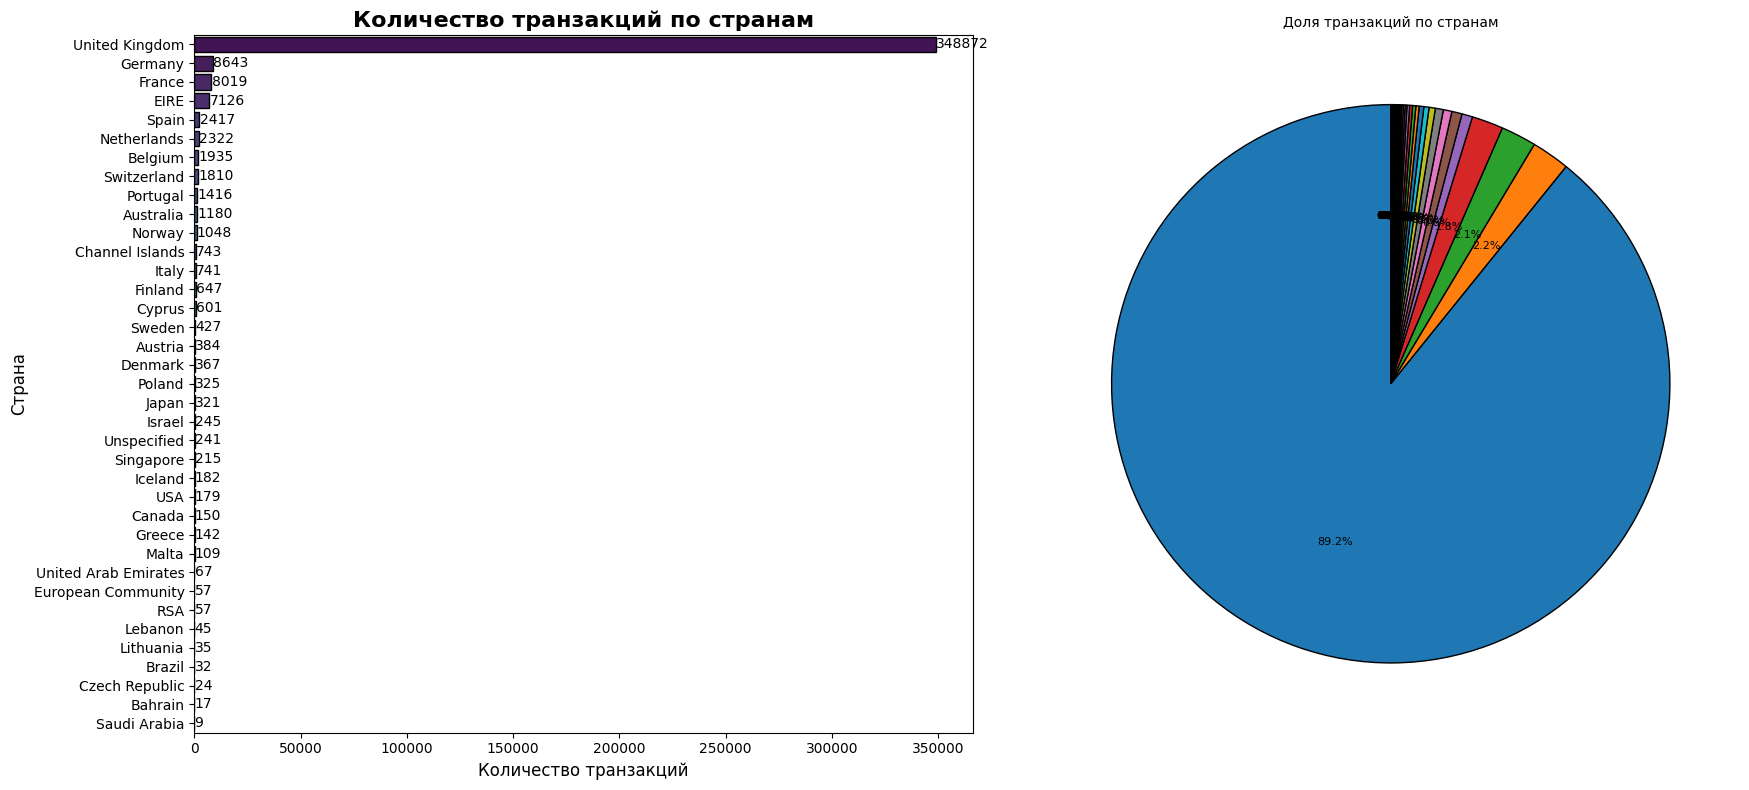

In [15]:
# строим столбчатую и круговую диаграмму распределения количества транзакций по странам
country_transactions  = data["Country"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x=country_transactions .values, y=country_transactions .index, ax=ax[0], palette="viridis")

ax[0].set_title("Количество транзакций по странам", fontsize=16, fontweight="bold")
ax[0].set_xlabel("Количество транзакций", fontsize=12)
ax[0].set_ylabel("Страна", fontsize=12)

for i, v in enumerate(country_transactions .values):
    ax[0].text(v + 100, i, str(v), va="center", fontsize=10)

country_transactions_prc = (country_transactions  / country_transactions .sum()) * 100
ax[1].pie(country_transactions , autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})
ax[1].set_title('Доля транзакций по странам', fontsize=10)

plt.tight_layout()
plt.show()

По графику выше, мы видим, что почти 90% это заказы из Великобритании, далее идут Германия (2.2%), Франция (2.1%) и Ирландия (1.8%), 

остальные 33 объекта занимают оставшиеся ~4.5-5% .

In [16]:
# строим круговую диаграмму доли странн в выручке, выведим в процентах только топ 8 странн, остальные 29 странн отделим выборкой
import plotly.io as pio
country_revenue = data.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
top_8 = country_revenue.head(8)
others = pd.Series({"Другие страны (29 шт)": country_revenue.iloc[8:].sum()})
plot_df = pd.concat([top_8, others])

pie = px.pie(plot_df, 
             values=plot_df.values, 
             names=plot_df.index,
             title="Доля стран в выручке",
             height=700, width=1500)
pie.show()
pio.write_html(pie, "pie.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/pie.html)

На графике выше отображена доля стран в выручке, по которой можно сказать, что 82% выручки приходится на Великобританию, из которой к нам поступает 90% всех заказов, 3.5% выручки к нам приходит от Нидерландов, если учесть, что Нидерланды составляют лишь половину процента от количества всех транзакций и заказов и даже не входят в топ 5 странн, то Нидерланды являются достаточно хорошим клиентом. Далее идет Ирландия, которая составляет 1.8% от количества всех заказов и приносит долю выручку в 3% от всех странн, далее идут страны, котоые приносят менее 2.5%. Также остальные 29 странн, выделенные в отдельную выборку приносят суммарно ~3.8 процента к выручке.

Обращяя внимание на такие страны как Нидерланды, которые имеют низкую долю в количестве заказов и долю выручки заметно превышающию долю заказов, можно составить некий коэффициент кпд, а точнее коэффициент эффективности каждой странны - KPI, этот коэффициент будет рассчитываться как доля выручки деленная на долю заказов, далее мы построим по этому коэффициенту график или диаграмму и найдем странны с высоким коэффициентом > 1 и с низким < 1, таким образом, странны у которых KPI будет низкий, это не перспективные страны, с большим количеством заказов, но с меньшим количеством денег, страны с высоким коэффициентом будут говорить о том, что у этих странн мало заказов, но много денег. Исходя из значений коэффициента KPI, можно составить несколько вариантов стратегий по наращиванию количества заказов и по наращиванию выручки.

In [17]:
# добавим коэффициент KPI в наши данные в виде признака, рассчитываться он будет, как доля выручки деленная на доля в транзакциях 
country_revenue = data.groupby("Country")["TotalPrice"].sum()
country_transactions = data.groupby("Country").size()

revenue_share = country_revenue / country_revenue.sum() * 100
transactions_share = country_transactions / country_transactions.sum() * 100

country_kpi = pd.DataFrame({
    "RevenueShare": revenue_share,
    "TransactionShare": transactions_share,
    "KPI": revenue_share / transactions_share
})

country_kpi = country_kpi.sort_values("KPI", ascending=False)
country_kpi["Country"] = country_kpi.index

kpi_high = country_kpi[country_kpi["KPI"] > 1].sort_values("KPI", ascending=False)
kpi_low = country_kpi[country_kpi["KPI"] < 1].sort_values("KPI", ascending=True)

# выведим на график страны с высоким и низким kpi: > 1 и < 1
import plotly.express as px

# График для KPI > 1
fig1 = px.bar(kpi_high, x="Country", y="KPI", 
              title="KPI > 1 (эффективные)",
              color="KPI", color_continuous_scale="Viridis",
              text="KPI")
fig1.update_traces(texttemplate='%{text:.2f}', textposition="outside")
fig1.update_xaxes(tickangle=-45)
fig1.show()
pio.write_html(fig1, "bar_head.html")

# График для KPI < 1
fig2 = px.bar(kpi_low, x="Country", y="KPI",
              title="KPI < 1 (неэффективные)",
              color="KPI", color_continuous_scale="Reds",
              text="KPI")
fig2.update_traces(texttemplate='%{text:.2f}', textposition="outside")
fig2.update_xaxes(tickangle=-45)
fig2.show()
pio.write_html(fig2, "bar_low.html")

**🌐 Интерактивная версия этого графика:**  

👉 [Кликни здесь, чтобы открыть график KPI > 1](https://sibainu2010.github.io/skillfactory_ds/bar_head.html)

👉 [Кликни здесь, чтобы открыть график KPI < 1](https://sibainu2010.github.io/skillfactory_ds/bar_low.html)

На графике с KPI > 1 самыми эффективными странами оказались Нидерланды, Австралия, Япония и Швейцария. Эти страны превышают ожидаемую от них выручку в 4-5 раз.

На графике с KPI < 1 самыми неэффективными странами оказались Польша, Канада, Италия и EС со средним значением KPI около или чуть меньше единицы.

Однако нельзя однозначно утверждать, что страны с высоким KPI идеальны как клиенты. Это может быть не так: например, в Нидерландах, которые отличаются высоким KPI, может быть всего один оптовик, который держит весь коэффициент на себе. Или же это могут быть разовые дорогостоящие (люксовые) покупки.

А страны с низким KPI не обязательно плохие клиенты. Хорошим коэффициентом можно считать KPI около 1.5, но при этом важна высокая доля заказов. Такие страны приносят и деньги, и большое количество заказов среднего или дорогого сегмента товаров. Иными словами, покупают часто и на хорошие суммы.

In [18]:
# построим график зависимости доли странн от доли транзакций 
scatter = px.scatter(country_kpi, 
                 x="TransactionShare", 
                 y="RevenueShare",
                 color="KPI",
                 size="KPI",
                 title="Эффективность стран: Доля выручки vs Доля транзакций",
                 color_continuous_scale="Viridis",
                 labels={"TransactionShare": "Доля транзакций (%)", 
                        "RevenueShare": "Доля выручки (%)"},
                 height=700, width=1500)

scatter.add_hline(y=country_kpi["RevenueShare"].mean(), line_dash="dash")
scatter.add_vline(x=country_kpi["TransactionShare"].mean(), line_dash="dash")
scatter.add_shape(type="line", x0=0, y0=0, x1=100, y1=100, 
              line=dict(color="red", dash="dash"))
scatter.show()
pio.write_html(scatter, "scatter.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/scatter.html)

На графике выше мы не получили особой информативности, так как наша целевая страна — Великобритания — отличилась самым высоким показателем доли транзакций в совокупности с долей выручки. Однако мы понимаем, что если учитывать долю выручки, долю транзакций и KPI (0,92) для этой страны, то получается вполне сбалансированная картина. В таком случае можно подтянуть KPI за счет увеличения доли выручки (увеличить средний чек), что может привести к хорошей модели. 

Стратегии на основе KPI:

*  KPI > 1.5 + Мало заказов = РАСТИТЬ (увеличивать количество заказов)
      - Пример: Нидерланды, Швейцария
      - Маркетинг: скидки на повторные покупки, программы лояльности

*  KPI > 1.5 + Много заказов = УДЕРЖИВАТЬ (идеальные клиенты)
      - Маркетинг: персональные предложения, VIP-обслуживание

*  KPI < 0.7 + Много заказов = ОПТИМИЗИРОВАТЬ (повышать чек)
      - Пример: некоторые страны с дешевыми товарами
      - Маркетинг: cross-sell, upsell, скидки на крупные заказы

*  KPI < 0.7 + Мало заказов = АНАЛИЗИРОВАТЬ (возможно, отказ)
      - Стоит ли продолжать работать с этим рынком?

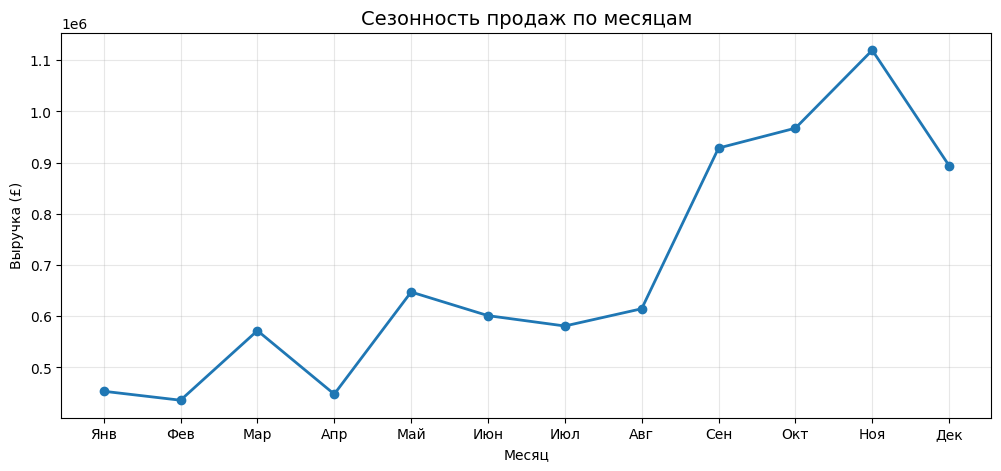

In [19]:
# построим график сезонности продаж по месяцам
data["Date"] = data["InvoiceDate"].dt.date
data["Month"] = data["InvoiceDate"].dt.month
data["Year"] = data["InvoiceDate"].dt.year

monthly_revenue = data.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", linewidth=2)
plt.title("Сезонность продаж по месяцам", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Выручка (£)")
plt.xticks(range(1, 13), ["Янв", "Фев", "Мар", "Апр", "Май", "Июн", 
                           "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"])
plt.grid(True, alpha=0.3)
plt.show()

По графике сезонности выше, мы наблюдаем глобальный минимум в феврале, локальный минимум в апреле, небольшой спад в июле и мощный подъем с августа по ноябрь и снова просадку в декабре, таким образом, можно заметить, что в нашем годовом цикле под конец года, в конце последней четверти (конец осени, начало и середина зимы), мы находимся в заметной просадке, в годичном минимум, далее можно было бы сопоставить наши даты с праздничными датами в UK и добавить их на этот график сезонности продаж, однако судя по нашим данным, наша компания не работала в праздники, поэтому мы к сожалению не сможем создать такой признак в наших данных.

Если говорить о наличие сезонности, то безусловно она присутствует в наших данных, и представляет собой восходящий тренд с начала года и нисходящий тренд с середени осени по середину зимы (3 месяца глобального годичного минимума).

Среднее количество заказов по часам:
 Hour  AvgOrdersPerDay
    6         1.000000
    7        16.304348
    8        42.274510
    9        86.456349
   10       123.953795
   11       158.582237
   12       231.855738
   13       207.947020
   14       176.252492
   15       148.222591
   16        89.492424
   17        70.475410
   18        61.361702
   19        65.897959
   20        55.500000

Пиковый час: 12:00 (231.9 заказов)


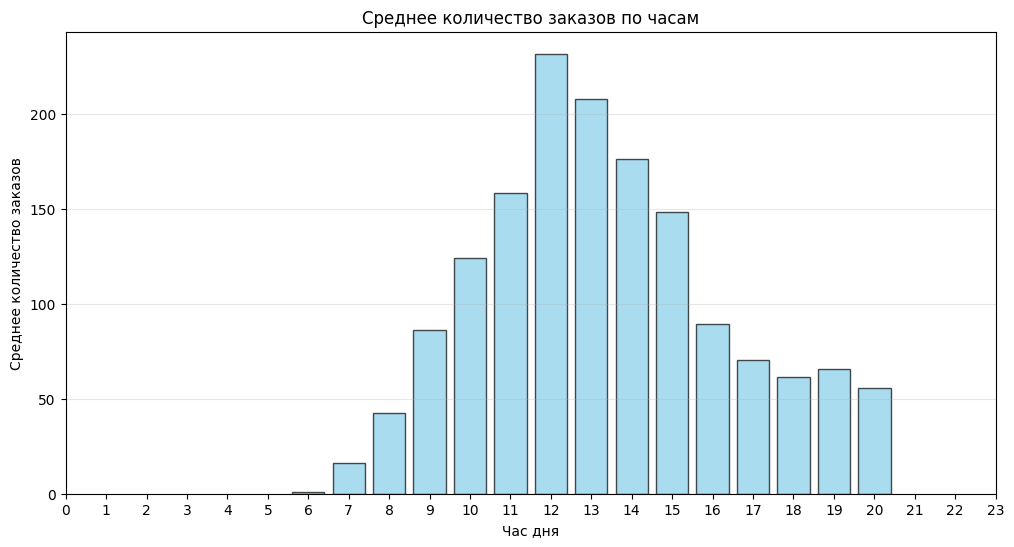

In [20]:
# построим столбчатую диаграмму распределения среднего количества транзакций в зависимости от времени суток (от часа)
data["Hour"] = data["InvoiceDate"].dt.hour

orders_by_day_hour = data.groupby(["Date", "Hour"]).size().reset_index(name="OrderCount")
avg_orders_by_hour = orders_by_day_hour.groupby("Hour")["OrderCount"].mean().reset_index()
avg_orders_by_hour.columns = ["Hour", "AvgOrdersPerDay"]

print("Среднее количество заказов по часам:")
print(avg_orders_by_hour.to_string(index=False))

peak_hour = avg_orders_by_hour.loc[avg_orders_by_hour["AvgOrdersPerDay"].idxmax()]
print(f"\nПиковый час: {int(peak_hour['Hour']):02d}:00 ({peak_hour['AvgOrdersPerDay']:.1f} заказов)")

plt.figure(figsize=(12, 6))
plt.bar(avg_orders_by_hour["Hour"], avg_orders_by_hour["AvgOrdersPerDay"], 
        color="skyblue", edgecolor="black", alpha=0.7)
plt.title("Среднее количество заказов по часам")
plt.xlabel("Час дня")
plt.ylabel("Среднее количество заказов")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, axis="y")
plt.show()

На графике среднего количества заказов по часам выше, мы видим перед собой нормальное распределение гауса, которое имеет пик в своей вершине равный 12 часам дня.

Также можно сказать, что в часы с 8 вечера, до 6, почти 7 утра, мы практически не имеем заказы, точнее не имеем заказов раньше 6 утра и вовсе.
Значит, в это время мы не принимали и не отправляли никакие заказы и не обрабатывали никакие транзакции, что видимо объясняется нашими часами работы. 

### 2.3. Построение RFM-таблицы и поиск RFM-выбросов

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

<center> <img src=https://miro.medium.com/max/1400/1*uYQjy9SUjW7iWHc2gGanQQ.png align="right" width="400"/> </center>

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.


Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов. 

Например, вот так может выглядеть интерпретация кластеров для случая RF-сегментации (анализа на основе давности и частоты заказов клиента):

<img src=https://retailrocket.ru/wp-content/uploads/2017/06/rfm-1.png>

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

In [21]:
# строим RFM таблицу 
rfm_table = data.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (pd.Timestamp("2011-12-10") - max(x)).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
    ).reset_index()

rfm_table.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,0.00
1,12347,2,7,4310.00
2,12348,75,4,1437.24
3,12349,18,1,1457.55
4,12350,310,1,294.40


In [22]:
# посмотрим на распределения каждого признака из нашей таблицы RFM, для этого построим коробчатые диаграммы 
cols = ['Recency', 'Frequency', 'Monetary']
boxes = [px.box(rfm_table, x=col) for col in cols]

fig = make_subplots(rows=1, cols=3, subplot_titles=cols)

for i, box in enumerate(boxes):
    fig.add_trace(box['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.show()
pio.write_html(fig, "boxes.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/boxes.html)

На графиках выше мы наблюдаем распределения наших трёх метрик RFM. Для признака давности (Recency) медиана равна 50: то есть в среднем между последней покупкой чаще всего проходит 50 дней. Третий квартиль равен 142 дням. Значения более 300 дней находятся за рамками нашего распределения, и, возможно, это уже «мёртвые» клиенты, которые заказали у нас всего один раз, и им что-то не понравилось (возможно, они даже вернули весь товар).

График метрики частоты (Frequency) указывает на то, что медианная частота покупок для нас равна 2, третий квартиль — 11. Также у нас имеются клиенты, которые купили товар более 11 раз, а именно в пределах от 50 доходя до 100. После значения в сто единиц мы, скорее всего, можем наблюдать выбросы в наших данных, которые стоит удалить.

Последний график справа показывает распределение третьей метрики — денежной ценности (Monetary). Её медианное значение находится на отметке 651 фунт стерлингов, третий квартиль — на отметке 1607 фунтов стерлингов. Также видны выбросы со значениями, превышающими 190 тысяч стерлингов.

### 2.2 Удалим выбросы в наших метриках RFM выходящие за пределы 95% описываемых данных

In [23]:
# удаляем выбросы из таблицы RFM 
from scipy import stats

rfm_clean = rfm_table[
    (rfm_table[['Recency', 'Frequency', 'Monetary']].apply(
        lambda x: (x >= x.quantile(0.025)) & (x <= x.quantile(0.975))
    ).all(axis=1))
]

In [24]:
# посмотрим на распределения каждого признака из нашей таблицы RFM после удаления выбросов 
cols = ['Recency', 'Frequency', 'Monetary']
boxes = [px.box(rfm_clean, x=col, height=700, width=1500) for col in cols]

fig = make_subplots(rows=1, cols=3, subplot_titles=cols)

for i, box in enumerate(boxes):
    fig.add_trace(box['data'][0], row=1, col=i+1)

fig.update_layout(showlegend=True)
fig.show()
pio.write_html(fig, "boxes_new.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/boxes_new.html)

Теперь мы удалили все выбросы, выходящие за пределы 95% описываемых данных.

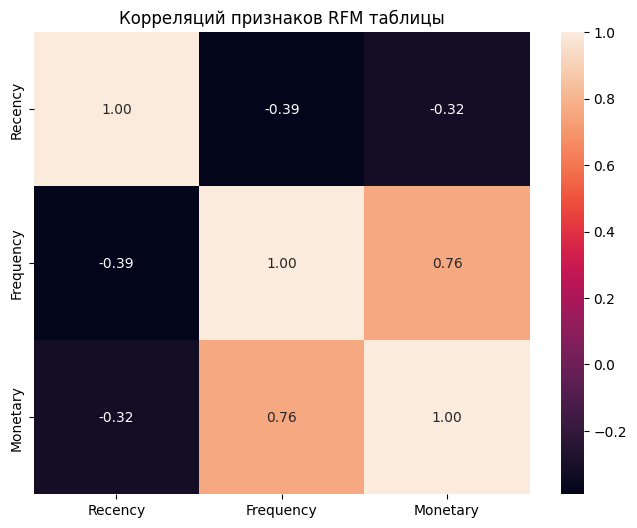

In [25]:
# также посмотрим уровень корреляции между метриками RFM таблицы
corr_matrix = rfm_clean[["Recency", "Frequency", "Monetary"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", 
            xticklabels=corr_matrix.columns, 
            yticklabels=corr_matrix.columns)
plt.title("Корреляций признаков RFM таблицы")
plt.show()

Сильной мультиколлениарности мы здесь не видим, видим лишь сильную связь признаков Денежной стоимости (Monetary) и Частоты (Frequence), логично предположить, что мы увидим эту связь в финале на этапе визуализации полученных кластеров. 

## 3. Моделирование и оценка качества моделей

### 3.1. Кластеризация на основе RFM-характеристик

Чтобы результаты кластеризации было удобнее интерпретировать, вы можем уменьшить размерность исходных признаков до двух компонент.

Произведем предобработку исходных данных. На основе RFM-признаков кластеризуем клиентов онлайн-магазина подарков с помощью известных методов (KMeans, AgglomerativeClustering, EM-кластеризация и DBSCAN).

Подберем оптимальное количество кластеров для выбранных методов с помощью коэффициента силуэта, перебирая возможные значения от 3 до 10 включительно.

Выберем алгоритм с наибольшим коэффициентом силуэта и в финальной части сделаем предсказание меток кластеров и проинтерпритируем их.

####  3.2 Подбор гиперпараметров 

In [26]:
# в данном блоке кода, я обучил каждую модель и предсказал метки кластеров на стандартизированных данных, 
# после чего в циклах перебрал и нашел лучшие значения гиперпараметров и значение силуэта (чем выше коэффициент силуэта, тем лучше, его распределение от -1, до 1), для каждой модели, 
# тем самым найдя лучшую модель по коэффициенту силуэта 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

X = rfm_clean[["Recency", "Frequency", "Monetary"]]

best_score = {}
best_params = {}

best_score["DBSCAN"] = -1
best_params["DBSCAN"] = None
for eps in [round(x/10, 1) for x in range(1, 10)]:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('dbscan', DBSCAN(eps=eps, n_jobs=-1))
    ])
    labels = pipeline.fit_predict(X)
    if len(set(labels)) > 1:
        X_scaled = pipeline.named_steps["scaler"].transform(X)
        score = silhouette_score(X_scaled, labels)
        if score > best_score["DBSCAN"]:
            best_score["DBSCAN"] = score
            best_params["DBSCAN"] = eps
            # print(f"DBSCAN | eps={eps} | score={score:.4f}")
    else:
        print(f"DBSCAN | eps={eps} | only {len(set(labels))} cluster(s), skipping")

best_score["KMeans"] = -1
best_params["KMeans"] = None
for k in range(3, 11):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    labels = pipeline.fit_predict(X)
    X_scaled = pipeline.named_steps["scaler"].transform(X)
    score = silhouette_score(X_scaled, labels)
    if score > best_score["KMeans"]:
        best_score["KMeans"] = score
        best_params["KMeans"] = k
        # print(f"KMeans | k={k} | score={score:.4f}")

best_score["AgglomerativeClustering"] = -1
best_params["AgglomerativeClustering"] = None
for k in range(3, 11):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('agg', AgglomerativeClustering(n_clusters=k))
    ])
    labels = pipeline.fit_predict(X)
    X_scaled = pipeline.named_steps["scaler"].transform(X)
    score = silhouette_score(X_scaled, labels)
    if score > best_score["AgglomerativeClustering"]:
        best_score["AgglomerativeClustering"] = score
        best_params["AgglomerativeClustering"] = k
        # print(f"AgglomerativeClustering | k={k} | score={score:.4f}")

best_score["GaussianMixture"] = -1
best_params["GaussianMixture"] = None
for k in range(3, 11):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('gmm', GaussianMixture(n_components=k, random_state=42, n_init=10))
    ])
    labels = pipeline.fit_predict(X)
    X_scaled = pipeline.named_steps["scaler"].transform(X)
    score = silhouette_score(X_scaled, labels)
    if score > best_score["GaussianMixture"]:
        best_score["GaussianMixture"] = score
        best_params["GaussianMixture"] = k
        # print(f"GaussianMixture | k={k} | score={score:.4f}")

for name in ["DBSCAN", "KMeans", "AgglomerativeClustering", "GaussianMixture"]:
    print(f"{name}: best={best_params[name]}, score={best_score[name]:.4f}")

best_method = max(best_score, key=best_score.get)
print(f"\nЛучший метод: {best_method} с параметром {best_params[best_method]}")

DBSCAN: best=0.8, score=0.5723
KMeans: best=3, score=0.4908
AgglomerativeClustering: best=3, score=0.4468
GaussianMixture: best=3, score=0.2079

Лучший метод: DBSCAN с параметром 0.8


После подбора гиперпараметров лучшими моделями для нас в порядке убывания оказались: 

1. DBSCAN (score=0.5723)
2. KMeans (score=0.4908)
3. AgglomerativeClustering (score=0.4468)
4. GaussianMixture (score=0.2079)

Так как у нас есть возможность понизить размерность наших данных до двух компонент с помощью метода PCA, то понизив размерность, мы сможем наглядно увидеть как именно модели смогли кластеризировать наши данные и на сколько хорошо, так как отталкиваться только от значений силэута не стоит.

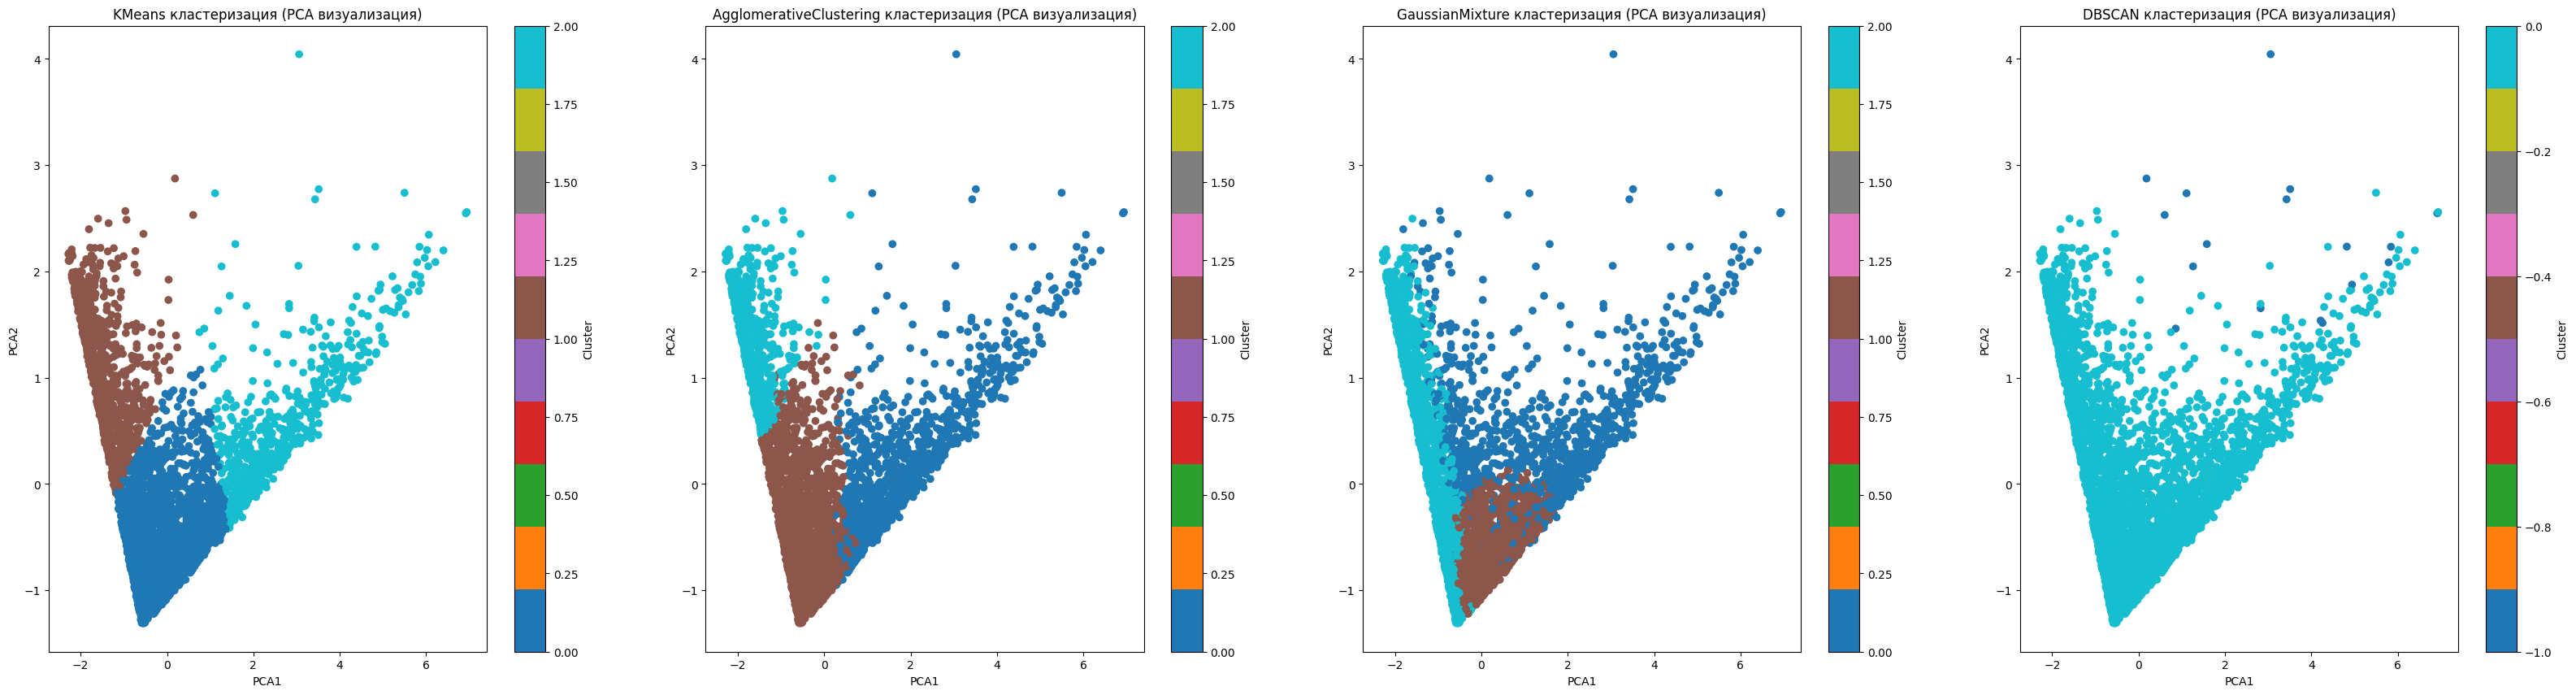

In [27]:
# обучим каждую модель с подобранными для нее ранее параметрами и визиулизируем с помощью метода главных компонент наши метки классов в формате 2d
from sklearn.decomposition import PCA 

best_KMeans = KMeans(random_state=42, n_init=10, n_clusters=best_params["KMeans"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels_KMeans = best_KMeans.fit_predict(X_scaled)
pca = PCA(random_state=42, n_components=2)
X_pca = pca.fit_transform(X_scaled)

best_Agglo = AgglomerativeClustering(n_clusters=best_params["AgglomerativeClustering"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels_Agglo = best_Agglo.fit_predict(X_scaled)
pca = PCA(random_state=42, n_components=2)
X_pca = pca.fit_transform(X_scaled)

best_Gaus = GaussianMixture(n_components=best_params["AgglomerativeClustering"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels_Gaus = best_Gaus.fit_predict(X_scaled)
pca = PCA(random_state=42, n_components=2)
X_pca = pca.fit_transform(X_scaled)

best_DBSCAN = DBSCAN(eps=best_params["DBSCAN"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels_DBSCAN = best_DBSCAN.fit_predict(X_scaled)
pca = PCA(random_state=42, n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 4, figsize=(40, 10))
scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_KMeans, cmap="tab10")
fig.colorbar(scatter, ax=axes[0], label="Cluster")
axes[0].set_xlabel("PCA1")
axes[0].set_ylabel("PCA2")
axes[0].set_title("KMeans кластеризация (PCA визуализация)")

scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_Agglo, cmap="tab10")
fig.colorbar(scatter, ax=axes[1], label="Cluster")
axes[1].set_xlabel("PCA1")
axes[1].set_ylabel("PCA2")
axes[1].set_title("AgglomerativeClustering кластеризация (PCA визуализация)")

scatter = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_Gaus, cmap="tab10")
fig.colorbar(scatter, ax=axes[2], label="Cluster")
axes[2].set_xlabel("PCA1")
axes[2].set_ylabel("PCA2")
axes[2].set_title("GaussianMixture кластеризация (PCA визуализация)")

scatter = axes[3].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_DBSCAN, cmap="tab10")
fig.colorbar(scatter, ax=axes[3], label="Cluster")
axes[3].set_xlabel("PCA1")
axes[3].set_ylabel("PCA2")
axes[3].set_title("DBSCAN кластеризация (PCA визуализация)")
plt.show()

По визуализациям ответов наших моделей выше можно сказать, что модель с самым высоким коэффициентом силуэта DBSCAN, оказалась самой плохой на практике, так как эта модель ищет плотности и на основе этого кластеризирует, таким образом этот метод не подошел под наши данные.

Метод Гауса (EM-кластеризация), показала худшее значения силуэта и также плохое значение на практике.

Остальные две модели (KMeans и AgglomerativeClustering) схожи по своему методу разбиения данных на кластеры, однако, метод KMeans показал выше значение внутрненней метрики, а также лучшую модель разбиения данных на 3 кластера, тем самым финальной моделью становится метод KMeans c 3 кластерами

In [28]:
# также посмотрим остальные метрики внутренних мер, для финальной модели на boostrap выборке 
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.model_selection import KFold 

X = rfm_clean[["Recency", "Frequency", "Monetary"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

n_splits = 5
n_clusters = 3
random_state = 42

silhouette_scores = []
calinski_scores = []
davies_scores = []

kf = KFold(random_state=random_state, shuffle=True, n_splits=n_splits)

for train_idx, test_idx in kf.split(X_scaled):
    X_train = X_scaled[train_idx]
    X_test = X_scaled[test_idx]
    
    model = KMeans(random_state=random_state, n_clusters=n_clusters, n_init=10)
    model.fit(X_scaled)
    
    test_predict = model.predict(X_test)
    
    if len(set(test_predict)) > 1:
        silhouette_scores.append(silhouette_score(X_test, test_predict))
        calinski_scores.append(calinski_harabasz_score(X_test, test_predict))
        davies_scores.append(davies_bouldin_score(X_test, test_predict))
        
print(f"CV Silhouette: mean={np.mean(silhouette_scores):.4f}, std={np.std(silhouette_scores):.4f}")
print(f"CV Calinski-Harabasz: mean={np.mean(calinski_scores):.4f}, std={np.std(calinski_scores):.4f}")
print(f"CV Davies_Bouldin: mean={np.mean(davies_scores):.4f}, std={np.std(davies_scores):.4f}")

CV Silhouette: mean=0.4910, std=0.0054
CV Calinski-Harabasz: mean=837.7243, std=31.6416
CV Davies_Bouldin: mean=0.7264, std=0.0105


Метрики у нашей модели вполне хорошие и устойчивые (стандартное отклонение около нуля)

### 3.2. Интерпретация результатов кластеризации

#### 3.2.1. Визуализация кластеров

Визуализируем результаты в виде 3D-диаграммы с осями Recency, Frequency и Monetary. Проанализируем полученную диаграмму и попробуем понять, какие кластеры у нас получились.

In [29]:
# визуализируем результаты в виде 3D-диаграммы с осями Recency, Frequency и Monetary
best_KMeans = KMeans(random_state=42, n_init=10, n_clusters=best_params["KMeans"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels_KMeans = best_KMeans.fit_predict(X_scaled)

scatter_3d = px.scatter_3d(rfm_clean,
                        x="Recency",
                        y="Frequency",
                        z="Monetary",
                        color_continuous_scale="viridis",
                        title="KMeans кластеризация (3d визуализация)",
                     color=labels_KMeans,
                     height=1000, width=1000)
scatter_3d.show()
pio.write_html(scatter_3d, "scatter_3d.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/scatter_3d.html)

Кластер с меткой 0, на 3d-диаграмме выше говорит нам о том, что это усредненные покупатели, со средним чеком в 1000-1500 фунтов стерлингов, с 3-5 покупками раз в 3-4 месяца. 

Кластер с меткой 1, показывает почти ушедших клиентов, которые сделали всего пару заказов на низкие суммы и с момента последнего заказа прошел уже почти год или чуть меньше года.

Кластер с меткой 2, показывает нам самых прибыльных клиентов, которые покупают часто, много ((от 7 до 11 в среднем)) и на крупые суммы (в среднем от 1500 до 4000). 

#### 3.2.2. Построение профиля кластеров

Далее составим так называемый профиль кластеров.

Сгруппируем RFM-таблицу по полученным кластерам и рассчитаем среднее по каждому из признаков.

Чтобы результаты было проще интерпретировать, давайте воспользуемся одним из способов визуализации профиля кластеров — **Radar Chart** (полярная диаграмма, или диаграмма паутины). Это графическое представление значений нескольких эквивалентных категорий в форме паутины.

Radar Chart часто используется при определении профиля кластеров. На концах паутины откладываются оси, соответствующие признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник.

In [33]:
from sklearn import preprocessing

def plot_cluster_profile(grouped_data, n_clusters):
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = preprocessing.MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаём список признаков
    features = grouped_data.columns
    # Создаём пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаём полярную диаграмму и добавляем её на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название — номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Отображаем фигуру
    fig.show()
    return fig

Теперь у вас есть удобный инструмент для анализа профиля кластеров. Воспользуйтесь им, чтобы проинтерпретировать результаты, полученные на предыдущем шаге.

In [34]:
# создаем диаграмму распределения данных на кластеры (RadarChart)
rfm_clean["cluster"] = labels_KMeans
grouped_data = rfm_clean.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean()

polar_chart = plot_cluster_profile(grouped_data, n_clusters=3)
pio.write_html(polar_chart, "polar_chart.html")

**🌐 Интерактивная версия этого графика:**  
👉 [Кликни здесь, чтобы открыть график](https://sibainu2010.github.io/skillfactory_ds/polar_chart.html)

На диаграмме выше мы видим три кластера, на которые метод K‑средних (KMeans) разделил наши данные.

Кластер 0 (синий) имеет по всем трём параметрам (Recency, Frequency, Monetary) практически одинаковые средние показатели. Это, скорее всего, «усреднённые» клиенты без ярко выраженного поведения.

Кластер 1 (красный) выделяется только одной метрикой — давностью (Recency). У таких клиентов последняя покупка была очень давно, а частота и денежная ценность низкие. Это потенциально «ушедшие» или «спящие» клиенты.

Кластер 2 (зелёный) имеет самые высокие значения по денежной ценности (Monetary) и частоте (Frequency) при низкой давности. Это лучшие клиенты — лояльные, активные и с высокими чеками. Также можно вспомнить, что при построении тепловой карты корреляции, мы уже видели сильную связь этих двух признаков Денежной ценности (Monetary) и Частоты (Frequency).

## 5. Выводы и оформление работы

Подводя заключение моей работы, я смог кластеризировать всех пользователей на три группы:

Группа 1 — средние клиенты. Покупают нормально, но без фанатизма. Их нужно стимулировать: скидки, бонусы, акции, предлагать доп товары.

Группа 2 — те, кто давно ничего не покупал. Скорее всего, потерялись. Им нужны реактивационные письма, промокоды на возврат, офферы "мы скучали".

Группа 3 — топ клиенты. Часто покупают и много тратят. Их главное - удержать: эксклюзивы, ранний доступ или вип-обслуживание.

RFM-кластеризация помогла разбить клиентов на типы и понять, с кем и как работать. Если правильно применить стратегии для каждой группы, можно поднять лояльность и выручку компании.